In [6]:
import results_deser as rd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## FMNIST+CNN Lambda grid search reaction

In [7]:

accs = [rd.load_testaccs("results/r_fmn_cnn_n2_lin_det"+str(i)) for i in range(3)]
df_init = pd.DataFrame(accs).transpose()
df_init.columns = ["experiment "+str(i) for i in range(3)]
lost_experiment_0 = np.array([
89.97,
91.58,
91.59,
91.12,
91.00])

df_init["experiment 0"] = lost_experiment_0
df_init["mean"] = df_init.mean(axis=1)
df_init

,experiment 0,experiment 1,experiment 2,mean
[1. 0.],89.97,88.96,89.96,89.630000
[0.875 0.125],91.58,91.33,91.14,91.350000
[0.75 0.25],91.59,91.56,91.35,91.500000
[0.625 0.375],91.12,91.06,90.69,90.956667
[0.5 0.5],91.00,90.66,90.33,90.663333


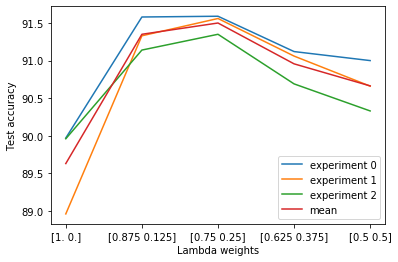

In [9]:
for col in df_init.columns:    
    plt.plot(df_init[col], label=col)
plt.xlabel("Lambda weights")
plt.ylabel("Test accuracy")
plt.legend()
plt.savefig('init_fmnist.pdf')  

## CIFAR10+ResNet18 Lambda grid search reaction

In [11]:
# cifar10
accs = [rd.load_testaccs("results/r_cf10_rn18_n2")]#+str(i)) for i in range(3)]
df_init10_1 = pd.DataFrame(accs).transpose()
#df_lin10 = df_lin10.transpose()
df_init10_1

,0
[1. 0.],84.74
[0.875 0.125],87.85
[0.75 0.25],88.55
[0.625 0.375],85.27
[0.5 0.5],82.37


In [12]:
accs = [rd.load_testaccs("results/r_cf10_rn18_n2_1")]
accs += [rd.load_testaccs("results/r_cf10_rn18_n2_grid0")]#+str(i)) for i in range(3)]
df_init10_2 = pd.DataFrame(accs).transpose()
df_init10_2[1] = df_init10_2.max(axis=1)
df_init10_2 = pd.DataFrame(df_init10_2[1])
df_init10_2

,1
[1. 0.],85.38
[0.875 0.125],87.10
[0.75 0.25],88.25
[0.625 0.375],85.96
[0.5 0.5],83.76


In [13]:
df_init10 = pd.DataFrame(index=df_init10_1.index)
df_init10["experiment 1"] = df_init10_1
df_init10["experiment 2"] = df_init10_2
df_init10["mean"] = df_init10.mean(axis=1)
df_init10

,experiment 1,experiment 2,mean
[1. 0.],84.74,85.38,85.060
[0.875 0.125],87.85,87.10,87.475
[0.75 0.25],88.55,88.25,88.400
[0.625 0.375],85.27,85.96,85.615
[0.5 0.5],82.37,83.76,83.065


In [14]:
print(df_init10.to_latex())

\begin{tabular}{lrrr}
\toprule
{} &  experiment 1 &  experiment 2 &    mean \\
\midrule
[1. 0.]       &         84.74 &         85.38 &  85.060 \\
[0.875 0.125] &         87.85 &         87.10 &  87.475 \\
[0.75 0.25]   &         88.55 &         88.25 &  88.400 \\
[0.625 0.375] &         85.27 &         85.96 &  85.615 \\
[0.5 0.5]     &         82.37 &         83.76 &  83.065 \\
\bottomrule
\end{tabular}



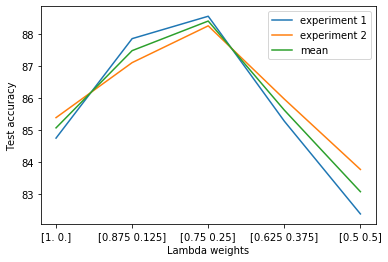

In [15]:
for col in df_init10.columns:    
    plt.plot(df_init10[col], label=col)
plt.xlabel("Lambda weights")
plt.ylabel("Test accuracy")
plt.legend()
plt.savefig('init_cifar10.pdf')